# TinyML Predictive Maintenance: Model Training

This notebook trains and compares different anomaly detection models for predictive maintenance.

In [3]:
import sys
import os
sys.path.append(os.path.join('..', 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split
import time

from tinyml_predictive_maintenance.data import generate_sensor_stream
from tinyml_predictive_maintenance.features import window_features
from tinyml_predictive_maintenance.model import (
    MahalanobisDetector,
    IsolationForestDetector,
    OneClassSVMDetector,
    create_detector
)

# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

## Data Preparation

Generate training data and extract features.

In [4]:
# Generate training data
df = generate_sensor_stream(samples=1000, anomaly_start=800, seed=42)
print(f"Generated {len(df)} training samples")

# Extract features
features_df = window_features(df, window_size=24, stride=12)
print(f"Extracted {len(features_df)} feature windows")

# Prepare feature matrix and labels
feature_cols = [col for col in features_df.columns if not col.startswith('window') and col != 'label']
X = features_df[feature_cols].values
y = features_df['label'].values

print(f"Feature matrix shape: {X.shape}")
print(f"Anomaly ratio: {np.mean(y):.3f}")

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Generated 1000 training samples
Extracted 82 feature windows
Feature matrix shape: (82, 21)
Anomaly ratio: 0.207
Training set: 57 samples
Test set: 25 samples


## Model Training and Evaluation

Train different anomaly detection models and compare their performance.

In [6]:
def evaluate_model(model, X_test, y_test, model_name):
    """Evaluate anomaly detection model performance."""
    start_time = time.time()
    predictions = model.predict(X_test)
    inference_time = time.time() - start_time
    
    # Calculate metrics
    tn, fp, fn, tp = confusion_matrix(y_test, predictions).ravel()
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    return {
        'model': model_name,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'accuracy': (tp + tn) / (tp + tn + fp + fn),
        'false_positive_rate': fp / (fp + tn) if (fp + tn) > 0 else 0,
        'inference_time_per_sample': inference_time / len(X_test),
        'predictions': predictions
    }

# Define models to train
models_config = [
    {'name': 'Mahalanobis Distance', 'type': 'mahalanobis', 'feature_names': feature_cols},
    {'name': 'Isolation Forest', 'type': 'isolation_forest', 'contamination': 0.1},
    {'name': 'One-Class SVM', 'type': 'one_class_svm', 'nu': 0.1}
]

results = []
trained_models = {}

for config in models_config:
    print(f"Training {config['name']}...")
    
    # Create and train model
    kwargs = {k: v for k, v in config.items() if k not in ['name', 'type']}
    model = create_detector(config['type'], **kwargs)
    model = model.fit(X_train, y_train)
    
    # Evaluate
    result = evaluate_model(model, X_test, y_test, config['name'])
    results.append(result)
    trained_models[config['name']] = model
    
    print(f"  F1-Score: {result['f1_score']:.3f}")
    print(f"  Precision: {result['precision']:.3f}")
    print(f"  Recall: {result['recall']:.3f}")
    print(f"  Inference time: {result['inference_time_per_sample']*1000:.2f} ms/sample")
    print()

Training Mahalanobis Distance...
  F1-Score: 1.000
  Precision: 1.000
  Recall: 1.000
  Inference time: 0.00 ms/sample

Training Isolation Forest...
  F1-Score: 0.333
  Precision: 1.000
  Recall: 0.200
  Inference time: 0.27 ms/sample

Training One-Class SVM...
  F1-Score: 0.727
  Precision: 0.667
  Recall: 0.800
  Inference time: 0.00 ms/sample



## Model Comparison

Compare the performance of different models.

In [7]:
# Create results DataFrame
results_df = pd.DataFrame(results).drop(columns=['predictions'])
print("Model Performance Comparison:")
results_df.round(4)

Model Performance Comparison:


,model,precision,recall,f1_score,accuracy,false_positive_rate,inference_time_per_sample
0,Mahalanobis Distance,1.0000,1.0,1.0000,1.00,0.0,0.0000
1,Isolation Forest,1.0000,0.2,0.3333,0.84,0.0,0.0003
2,One-Class SVM,0.6667,0.8,0.7273,0.88,0.1,0.0000


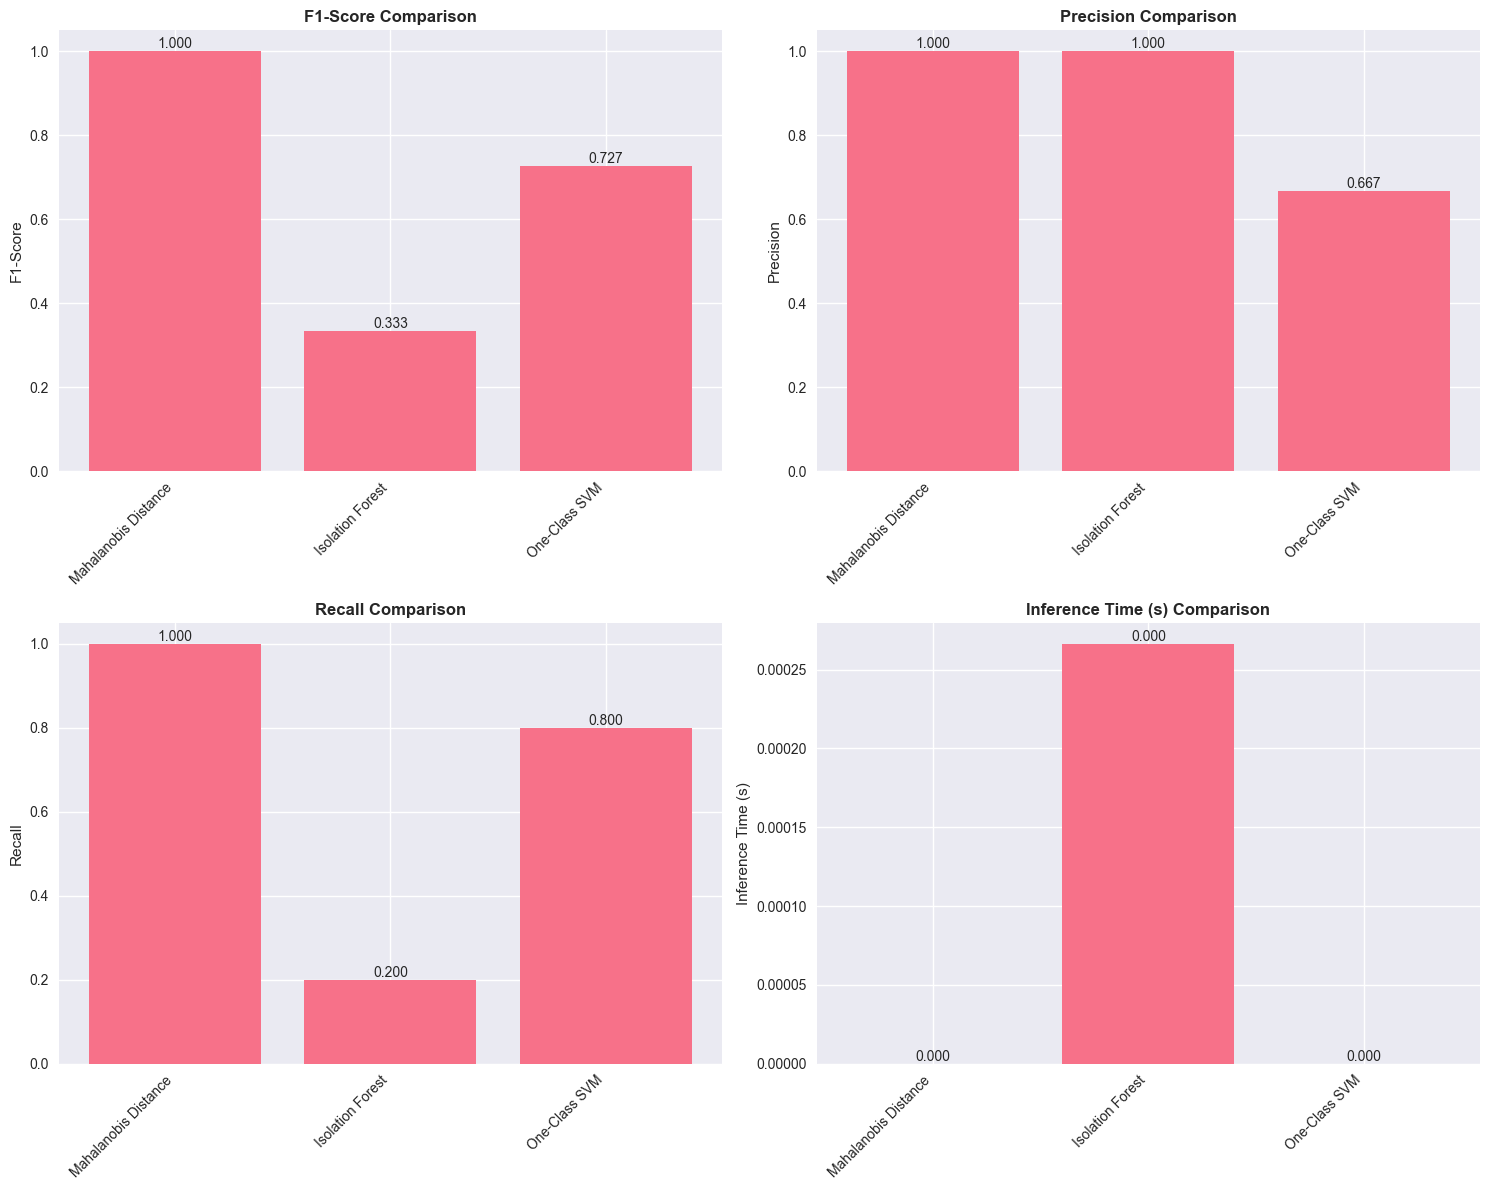

In [8]:
# Visualize performance comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

metrics = ['f1_score', 'precision', 'recall', 'inference_time_per_sample']
metric_names = ['F1-Score', 'Precision', 'Recall', 'Inference Time (s)']

for i, (metric, name) in enumerate(zip(metrics, metric_names)):
    ax = axes[i//2, i%2]
    bars = ax.bar(results_df['model'], results_df[metric])
    ax.set_title(f'{name} Comparison', fontsize=12, fontweight='bold')
    ax.set_ylabel(name)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom')
    
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

## Confusion Matrices

Visualize the confusion matrices for each model.

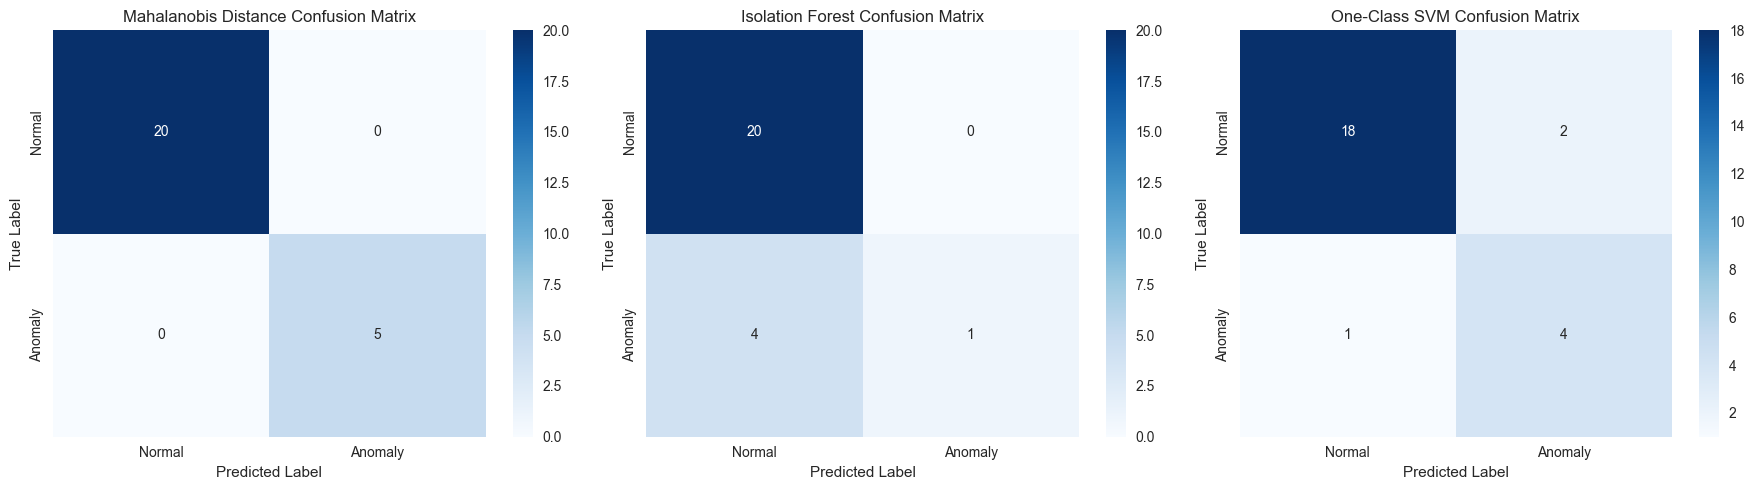

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, result in enumerate(results):
    cm = confusion_matrix(y_test, result['predictions'])
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
    axes[i].set_title(f'{result["model"]} Confusion Matrix')
    axes[i].set_ylabel('True Label')
    axes[i].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

## ROC Curves

Plot ROC curves to compare model discrimination ability.

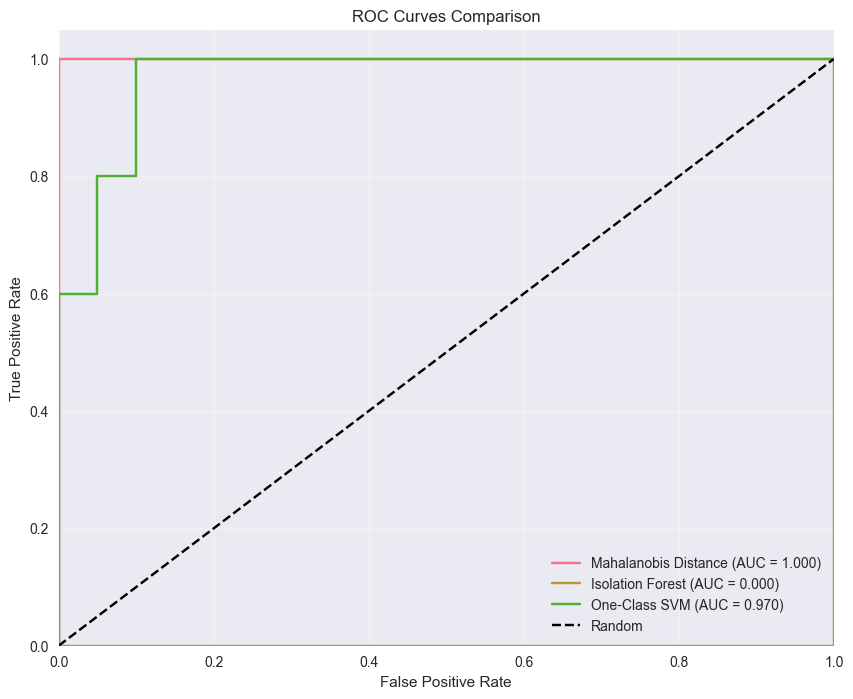

In [10]:
plt.figure(figsize=(10, 8))

for result in results:
    model = trained_models[result['model']]
    
    # Get anomaly scores
    if hasattr(model, 'score'):
        scores = model.score(X_test)
        # For some models, higher scores indicate more anomalous
        if result['model'] == 'Isolation Forest':
            scores = -scores  # Flip for consistency
    else:
        scores = result['predictions'].astype(float)
    
    fpr, tpr, _ = roc_curve(y_test, scores)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f'{result["model"]} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

## Model Interpretability

Analyze which features are most important for the Mahalanobis detector.

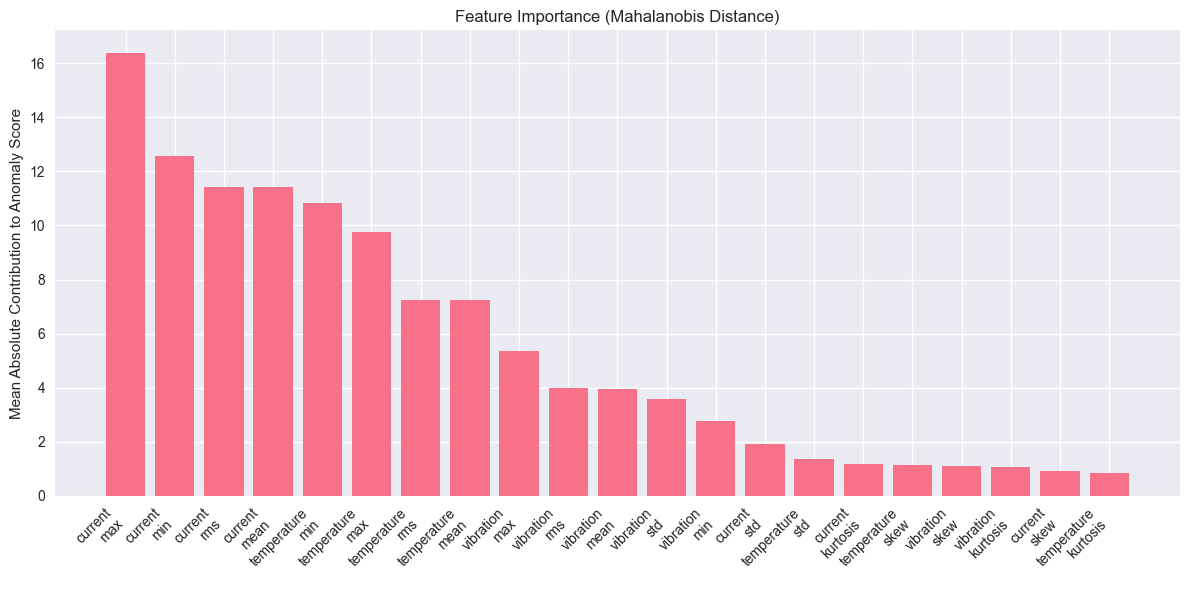

Top 5 most important features:


,feature,importance
16,current_max,16.390393
17,current_min,12.555059
18,current_rms,11.430890
14,current_mean,11.411288
10,temperature_min,10.836329


In [11]:
# Feature importance for Mahalanobis detector
mahal_model = trained_models['Mahalanobis Distance']

# Calculate feature contributions to anomaly scores
feature_contributions = np.abs(X_test - mahal_model.center_array) / mahal_model.scale_array
mean_contributions = np.mean(feature_contributions, axis=0)

# Create feature importance DataFrame
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': mean_contributions
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(feature_importance)), feature_importance['importance'])
plt.xticks(range(len(feature_importance)), 
           [f.replace('_', '\n') for f in feature_importance['feature']], 
           rotation=45, ha='right')
plt.title('Feature Importance (Mahalanobis Distance)')
plt.ylabel('Mean Absolute Contribution to Anomaly Score')
plt.tight_layout()
plt.show()

print("Top 5 most important features:")
feature_importance.head()

## Model Selection and Saving

Select the best model and save it for deployment.

In [12]:
# Select best model based on F1-score
best_model_name = results_df.loc[results_df['f1_score'].idxmax(), 'model']
best_model = trained_models[best_model_name]

print(f"Best model: {best_model_name}")
print(f"F1-Score: {results_df.loc[results_df['model'] == best_model_name, 'f1_score'].values[0]:.3f}")

# Save the best model
model_path = f"../models/{best_model_name.lower().replace(' ', '_')}_model.pkl"
os.makedirs(os.path.dirname(model_path), exist_ok=True)
best_model.save(model_path)
print(f"Model saved to: {model_path}")

Best model: Mahalanobis Distance
F1-Score: 1.000
Model saved to: ../models/mahalanobis_distance_model.pkl


## Summary

This notebook demonstrated:
1. Training multiple anomaly detection algorithms
2. Comprehensive model evaluation and comparison
3. Performance visualization and analysis
4. Feature importance analysis
5. Model selection and persistence

The results show that different models have different strengths - some prioritize precision while others focus on recall, depending on the use case requirements.